                         GENERALIZATION GAP ANALYSIS (AUC_TCGA - AUC_CGGA)                          
File loaded from: ../V15_results_final.csv
Dataset shape: (56, 10)
Models: 7
Pipelines: 4

         TABLE: Generalization Gap (AUC_TCGA - AUC_CGGA) for Each Model         

Generalization Gap (sorted by largest drop first):

       Model     Pipeline  TCGA_AUC  CGGA_AUC    Gap  Percent_Drop
       SGNN        SMOTE    0.8418    0.6273 0.2145         25.48
       SGNN No Balancing    0.8469    0.6401 0.2068         24.42
FastHGTConv          ROS    0.9171    0.7215 0.1956         21.33
       SGNN        CTGAN    0.8341    0.6398 0.1943         23.29
       RGCN        SMOTE    0.8338    0.6687 0.1651         19.80
       SGNN          ROS    0.8405    0.6833 0.1572         18.70
      MOGAT No Balancing    0.9206    0.7688 0.1518         16.49
       VEGN        SMOTE    0.8289    0.6834 0.1455         17.55
       RGCN No Balancing    0.8259    0.6819 0.1440         17.44
       VEGN N

,Model,Pipeline,TCGA_AUC,CGGA_AUC,Gap,Percent_Drop
25,SGNN,SMOTE,0.8418,0.6273,0.2145,25.48%
24,SGNN,No Balancing,0.8469,0.6401,0.2068,24.42%
23,FastHGTConv,ROS,0.9171,0.7215,0.1956,21.33%
26,SGNN,CTGAN,0.8341,0.6398,0.1943,23.29%
13,RGCN,SMOTE,0.8338,0.6687,0.1651,19.80%
27,SGNN,ROS,0.8405,0.6833,0.1572,18.70%
4,MOGAT,No Balancing,0.9206,0.7688,0.1518,16.49%
17,VEGN,SMOTE,0.8289,0.6834,0.1455,17.55%
12,RGCN,No Balancing,0.8259,0.6819,0.1440,17.44%
16,VEGN,No Balancing,0.8287,0.6847,0.1440,17.38%



                          SUMMARY STATISTICS BY MODEL                           

              Mean_Gap  Std_Gap  Min_Gap  Max_Gap  Mean_%Drop  Std_%Drop
Model                                                                  
SGNN           0.1932   0.0254   0.1572   0.2145     22.9743     2.9841
FastHGTConv    0.1462   0.0333   0.1229   0.1956     16.1525     3.5201
RGCN           0.1455   0.0138   0.1336   0.1651     17.5795     1.5507
VEGN           0.1423   0.0030   0.1391   0.1455     17.1954     0.3286
HyperTMO       0.1346   0.0051   0.1289   0.1409     16.2672     0.5570
MOGAT          0.1338   0.0170   0.1138   0.1518     14.8255     2.1334
HeteroGATv2    0.1169   0.0210   0.0863   0.1341     13.1931     2.3202
--------------------------------------------------------------------------------

                         SUMMARY STATISTICS BY PIPELINE                         

               Mean_Gap  Std_Gap  Min_Gap  Max_Gap  Mean_%Drop  Std_%Drop
Pipeline                      

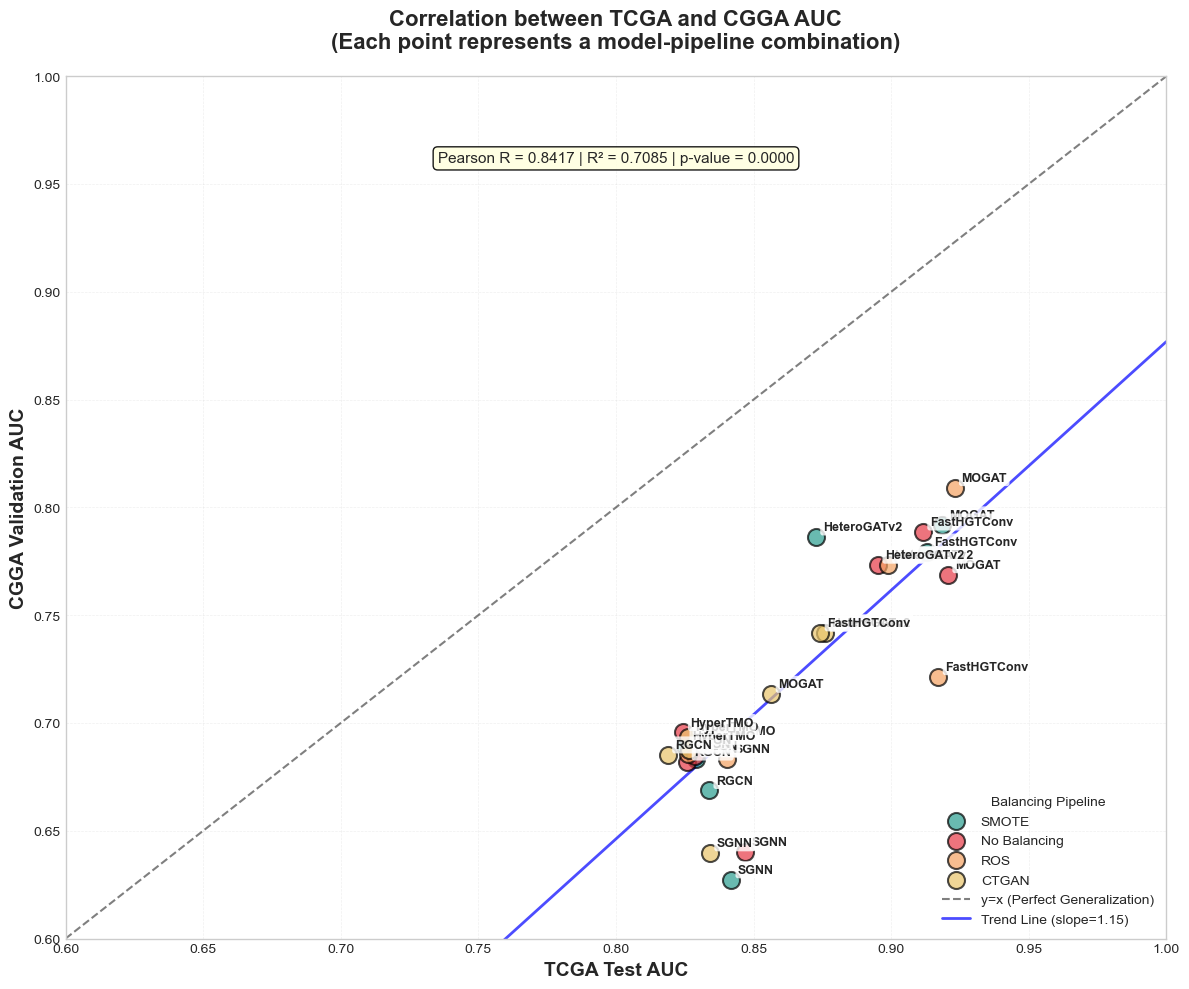


                           GENERALIZATION GAP HEATMAP                           


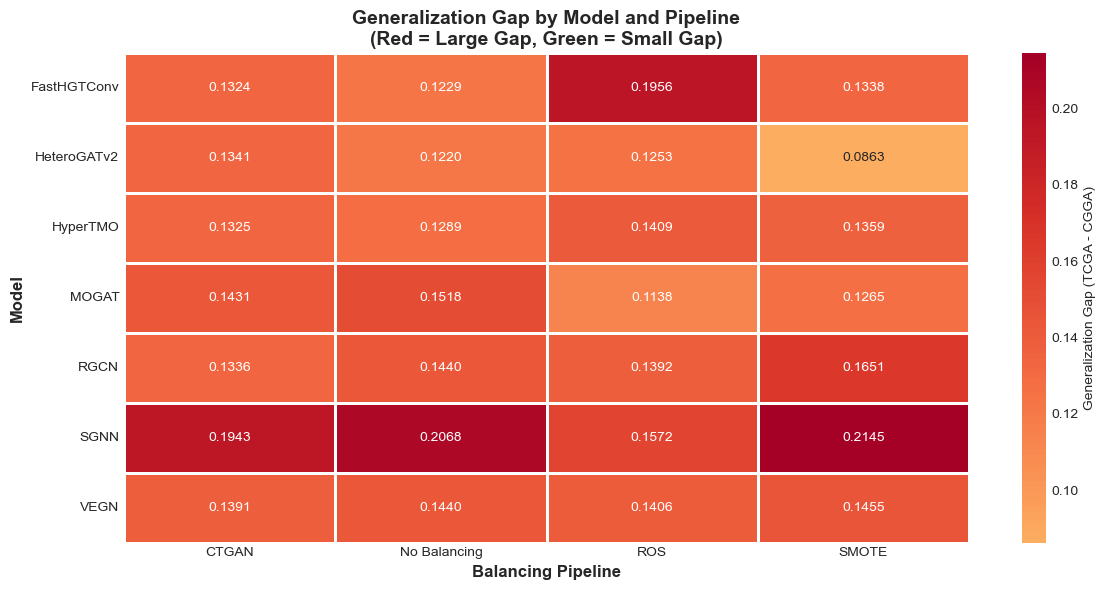


                      AVERAGE GENERALIZATION GAP BY MODEL                       


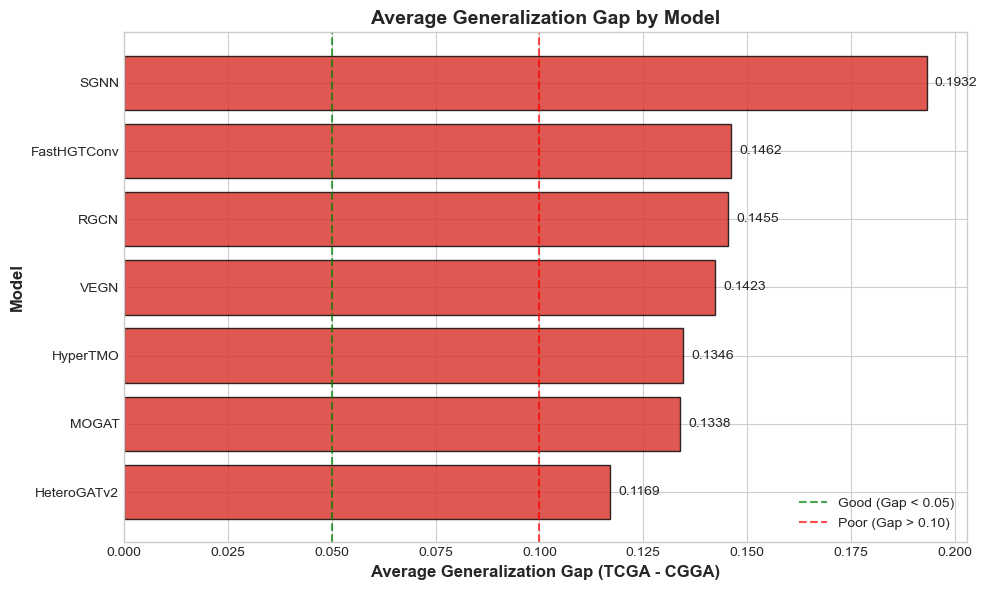


                            EXPORTING TABLES TO CSV                             
Exported files to current directory:
- generalization_gap.csv
- model_gap_summary.csv
- pipeline_gap_summary.csv
- best_generalizers.csv
- worst_generalizers.csv
- tcga_cgga_correlation_simple.png
- generalization_gap_heatmap.png
- avg_gap_by_model.png

                               ANALYSIS COMPLETE                                

                                  KEY FINDINGS                                  

• Pearson Correlation: 0.8417 (p=0.0000)
• Mean Generalization Gap: 0.1446
• Best Generalizing: HeteroGATv2 (SMOTE) - Gap: 0.0863
• Worst Generalizing: SGNN (SMOTE) - Gap: 0.2145



In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML
import matplotlib.patches as mpatches

# Read the CSV file from the parent directory
df = pd.read_csv('../V15_results_final.csv')

# Set style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("="*100)
print("GENERALIZATION GAP ANALYSIS (AUC_TCGA - AUC_CGGA)".center(100))
print("="*100)
print(f"File loaded from: ../V15_results_final.csv")
print(f"Dataset shape: {df.shape}")
print(f"Models: {df['Model'].nunique()}")
print(f"Pipelines: {df['Pipeline'].nunique()}")
print("="*100)

# 1. Create table of generalization gaps for each model
print("\n" + "="*80)
print("TABLE: Generalization Gap (AUC_TCGA - AUC_CGGA) for Each Model".center(80))
print("="*80)

# Prepare data for generalization gap table
gap_data = []
models = df['Model'].unique()
pipelines = df['Pipeline'].unique()

for model in models:
    for pipeline in pipelines:
        # Get TCGA and CGGA AUC for this model-pipeline combination
        tcga_auc = df[(df['Model'] == model) & 
                      (df['Pipeline'] == pipeline) & 
                      (df['Dataset'] == 'TCGA Test')]['AUC'].values
        cgga_auc = df[(df['Model'] == model) & 
                      (df['Pipeline'] == pipeline) & 
                      (df['Dataset'] == 'CGGA')]['AUC'].values
        
        if len(tcga_auc) > 0 and len(cgga_auc) > 0:
            tcga_val = tcga_auc[0]
            cgga_val = cgga_auc[0]
            gap = tcga_val - cgga_val
            percent_drop = (gap / tcga_val) * 100
            
            gap_data.append({
                'Model': model,
                'Pipeline': pipeline,
                'TCGA_AUC': tcga_val,
                'CGGA_AUC': cgga_val,
                'Gap': gap,
                'Percent_Drop': percent_drop
            })

gap_df = pd.DataFrame(gap_data)

# Sort by gap (largest drop first)
gap_df = gap_df.sort_values('Gap', ascending=False)

# Format the dataframe for display
display_df = gap_df.copy()
display_df['TCGA_AUC'] = display_df['TCGA_AUC'].round(4)
display_df['CGGA_AUC'] = display_df['CGGA_AUC'].round(4)
display_df['Gap'] = display_df['Gap'].round(4)
display_df['Percent_Drop'] = display_df['Percent_Drop'].round(2)

print("\nGeneralization Gap (sorted by largest drop first):")
print("\n", display_df.to_string(index=False))
print("-" * 80)

# Create styled table with color coding based on gap
def color_gap(val):
    """
    Color code the generalization gap:
    - Green: Small gap (< 0.05)
    - Yellow: Medium gap (0.05 - 0.10)
    - Orange: Large gap (0.10 - 0.15)
    - Red: Very large gap (> 0.15)
    """
    if val < 0.05:
        color = '#90EE90'  # Light green
    elif val < 0.10:
        color = '#FFFFE0'  # Light yellow
    elif val < 0.15:
        color = '#FFD700'  # Gold
    else:
        color = '#FFB6C1'  # Light red
    return f'background-color: {color}'

styled_gap = display_df.style.map(color_gap, subset=['Gap'])\
                           .format({'TCGA_AUC': '{:.4f}', 'CGGA_AUC': '{:.4f}', 
                                   'Gap': '{:.4f}', 'Percent_Drop': '{:.2f}%'})\
                           .set_properties(**{'text-align': 'center'})\
                           .set_table_styles([
                               {'selector': 'th', 
                                'props': [('font-weight', 'bold'), 
                                         ('text-align', 'center'),
                                         ('background-color', '#f0f0f0')]},
                               {'selector': 'td', 
                                'props': [('text-align', 'center')]}
                           ])

print("\nStyled Table (color-coded by gap size):")
display(styled_gap)

# 2. Summary statistics by model
print("\n" + "="*80)
print("SUMMARY STATISTICS BY MODEL".center(80))
print("="*80)

model_summary = gap_df.groupby('Model').agg({
    'Gap': ['mean', 'std', 'min', 'max'],
    'Percent_Drop': ['mean', 'std']
}).round(4)

model_summary.columns = ['Mean_Gap', 'Std_Gap', 'Min_Gap', 'Max_Gap', 'Mean_%Drop', 'Std_%Drop']
model_summary = model_summary.sort_values('Mean_Gap', ascending=False)

print("\n", model_summary.to_string())
print("-" * 80)

# 3. Summary statistics by pipeline
print("\n" + "="*80)
print("SUMMARY STATISTICS BY PIPELINE".center(80))
print("="*80)

pipeline_summary = gap_df.groupby('Pipeline').agg({
    'Gap': ['mean', 'std', 'min', 'max'],
    'Percent_Drop': ['mean', 'std']
}).round(4)

pipeline_summary.columns = ['Mean_Gap', 'Std_Gap', 'Min_Gap', 'Max_Gap', 'Mean_%Drop', 'Std_%Drop']
pipeline_summary = pipeline_summary.sort_values('Mean_Gap')

print("\n", pipeline_summary.to_string())
print("-" * 80)

# 4. Find best and worst generalizing models
print("\n" + "="*80)
print("BEST AND WORST GENERALIZING MODELS".center(80))
print("="*80)

best_generalizers = gap_df.nsmallest(3, 'Gap')[['Model', 'Pipeline', 'TCGA_AUC', 'CGGA_AUC', 'Gap', 'Percent_Drop']]
worst_generalizers = gap_df.nlargest(3, 'Gap')[['Model', 'Pipeline', 'TCGA_AUC', 'CGGA_AUC', 'Gap', 'Percent_Drop']]

print("\nTop 3 Best Generalizing Models (Smallest Gap):")
print(best_generalizers.to_string(index=False))

print("\nTop 3 Worst Generalizing Models (Largest Gap):")
print(worst_generalizers.to_string(index=False))

# 5. Create SIMPLE and CLEAN Scatter Plot
print("\n" + "="*80)
print("SCATTER PLOT: Correlation between TCGA AUC and CGGA AUC".center(80))
print("="*80)

# Prepare data for scatter plot
scatter_data = []
for _, row in gap_df.iterrows():
    scatter_data.append({
        'Model': row['Model'],
        'Pipeline': row['Pipeline'],
        'TCGA_AUC': row['TCGA_AUC'],
        'CGGA_AUC': row['CGGA_AUC'],
        'Gap': row['Gap']
    })

scatter_df = pd.DataFrame(scatter_data)

# Calculate correlation
correlation = scatter_df['TCGA_AUC'].corr(scatter_df['CGGA_AUC'])
p_value = stats.pearsonr(scatter_df['TCGA_AUC'], scatter_df['CGGA_AUC'])[1]

print(f"\nPearson Correlation Coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"R²: {correlation**2:.4f}")

# Create a simple, clean scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

# Define colors for different pipelines (color only, no size variation)
pipeline_colors = {
    'No Balancing': '#E63946',  # Red
    'SMOTE': '#2A9D8F',          # Teal
    'CTGAN': '#E9C46A',          # Gold
    'ROS': '#F4A261'              # Orange
}

# Plot each pipeline with different color
for pipeline in scatter_df['Pipeline'].unique():
    pipeline_data = scatter_df[scatter_df['Pipeline'] == pipeline]
    ax.scatter(pipeline_data['TCGA_AUC'], pipeline_data['CGGA_AUC'], 
              c=pipeline_colors[pipeline], 
              s=150,  # Fixed size
              alpha=0.7, 
              edgecolors='black', 
              linewidth=1.5,
              label=pipeline,
              zorder=5)

# Add model labels
for _, row in scatter_df.iterrows():
    ax.annotate(row['Model'], 
                (row['TCGA_AUC'], row['CGGA_AUC']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', 
                         facecolor='white', 
                         edgecolor='none',
                         alpha=0.8),
                zorder=10)

# Add diagonal line (y=x)
x_line = np.linspace(0.6, 1.0, 100)
ax.plot(x_line, x_line, 'k--', alpha=0.5, linewidth=1.5, label='y=x (Perfect Generalization)', zorder=1)

# Add trend line
z = np.polyfit(scatter_df['TCGA_AUC'], scatter_df['CGGA_AUC'], 1)
p = np.poly1d(z)
ax.plot(x_line, p(x_line), 'b-', alpha=0.7, linewidth=2, 
         label=f'Trend Line (slope={z[0]:.2f})', zorder=2)

# Customize plot
ax.set_xlabel('TCGA Test AUC', fontsize=14, fontweight='bold')
ax.set_ylabel('CGGA Validation AUC', fontsize=14, fontweight='bold')
ax.set_title('Correlation between TCGA and CGGA AUC\n(Each point represents a model-pipeline combination)', 
              fontsize=16, fontweight='bold', pad=20)

ax.set_xlim(0.6, 1.0)
ax.set_ylim(0.6, 1.0)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add statistics in a box at the top
stats_text = (f'Pearson R = {correlation:.4f} | R² = {correlation**2:.4f} | p-value = {p_value:.4f}')
ax.text(0.5, 0.9, stats_text, transform=ax.transAxes, fontsize=11,
        horizontalalignment='center',
        bbox=dict(boxstyle='round,pad=0.3', 
                 facecolor='lightyellow', 
                 edgecolor='black',
                 alpha=0.9))

# Add legend in a clean position
ax.legend(loc='lower right', fontsize=10, framealpha=0.95, title='Balancing Pipeline')

plt.tight_layout()
plt.savefig('tcga_cgga_correlation_simple.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Create heatmap
print("\n" + "="*80)
print("GENERALIZATION GAP HEATMAP".center(80))
print("="*80)

# Pivot data for heatmap
gap_pivot = gap_df.pivot_table(values='Gap', index='Model', columns='Pipeline', aggfunc='mean')

# Create heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(gap_pivot, annot=True, fmt='.4f', cmap='RdYlGn_r', center=0,
            linewidths=1, linecolor='white', 
            cbar_kws={'label': 'Generalization Gap (TCGA - CGGA)'})
plt.title('Generalization Gap by Model and Pipeline\n(Red = Large Gap, Green = Small Gap)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Balancing Pipeline', fontsize=12, fontweight='bold')
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('generalization_gap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Create simple bar plot
print("\n" + "="*80)
print("AVERAGE GENERALIZATION GAP BY MODEL".center(80))
print("="*80)

plt.figure(figsize=(10, 6))

model_avg_gap = gap_df.groupby('Model')['Gap'].mean().sort_values()
colors = ['#D73027' if x > 0.1 else '#FEE08B' if x > 0.05 else '#A6D96A' for x in model_avg_gap.values]

bars = plt.barh(range(len(model_avg_gap)), model_avg_gap.values, color=colors, alpha=0.8, 
                edgecolor='black', linewidth=1)

plt.yticks(range(len(model_avg_gap)), model_avg_gap.index)
plt.xlabel('Average Generalization Gap (TCGA - CGGA)', fontsize=12, fontweight='bold')
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.title('Average Generalization Gap by Model', fontsize=14, fontweight='bold')

# Add threshold lines
plt.axvline(x=0.05, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (Gap < 0.05)')
plt.axvline(x=0.10, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Poor (Gap > 0.10)')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, model_avg_gap.values)):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', fontsize=10)

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('avg_gap_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Export all tables to CSV
print("\n" + "="*80)
print("EXPORTING TABLES TO CSV".center(80))
print("="*80)

gap_df.to_csv('generalization_gap.csv', index=False)
model_summary.to_csv('model_gap_summary.csv')
pipeline_summary.to_csv('pipeline_gap_summary.csv')
best_generalizers.to_csv('best_generalizers.csv', index=False)
worst_generalizers.to_csv('worst_generalizers.csv', index=False)

print("Exported files to current directory:")
print("- generalization_gap.csv")
print("- model_gap_summary.csv")
print("- pipeline_gap_summary.csv")
print("- best_generalizers.csv")
print("- worst_generalizers.csv")
print("- tcga_cgga_correlation_simple.png")
print("- generalization_gap_heatmap.png")
print("- avg_gap_by_model.png")

print("\n" + "="*80)
print("ANALYSIS COMPLETE".center(80))
print("="*80)

# 9. Print key findings
print("\n" + "="*80)
print("KEY FINDINGS".center(80))
print("="*80)

print(f"\n• Pearson Correlation: {correlation:.4f} (p={p_value:.4f})")
print(f"• Mean Generalization Gap: {gap_df['Gap'].mean():.4f}")
print(f"• Best Generalizing: {best_generalizers.iloc[0]['Model']} ({best_generalizers.iloc[0]['Pipeline']}) - Gap: {best_generalizers.iloc[0]['Gap']:.4f}")
print(f"• Worst Generalizing: {worst_generalizers.iloc[0]['Model']} ({worst_generalizers.iloc[0]['Pipeline']}) - Gap: {worst_generalizers.iloc[0]['Gap']:.4f}")

print("\n" + "="*80)